# 19 - 複数モデル比較分析

## 概要
各モデルの評価結果をロードし、比較分析を行う。

## 比較観点
1. **クラスタリング品質** - シルエットスコア
2. **構造保持度** - Trustworthiness
3. **カテゴリ分離度** - 距離比
4. **処理性能** - 処理時間、埋め込み次元数

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from image_vector_poc.evaluation import EvaluationReporter

## 評価結果の読み込み

In [2]:
OUTPUT_DIR = Path("../data/evaluations")

reporter = EvaluationReporter(OUTPUT_DIR)
all_metrics = reporter.load_all()

print(f"Loaded {len(all_metrics)} evaluation results:")
for m in all_metrics:
    print(f"  - {m.model_name} (dim={m.embedding_dim})")

Loaded 8 evaluation results:
  - google/siglip-base-patch16-224 (dim=768)
  - openai/clip-vit-large-patch14 (dim=768)
  - facebook/dinov2-large (dim=1024)
  - openclip/ViT-H-14/laion2b_s32b_b79k (dim=1024)
  - google/siglip-base-patch16-224 (dim=768)
  - openai/clip-vit-large-patch14 (dim=768)
  - facebook/dinov2-large (dim=1024)
  - openclip/ViT-H-14/laion2b_s32b_b79k (dim=1024)


## 比較データフレームの作成

In [3]:
# モデル名を短縮形に変換
def get_short_name(model_name: str) -> str:
    """Extract short model name for display."""
    if "siglip" in model_name.lower():
        return "SigLIP"
    elif "openclip" in model_name.lower():
        return "OpenCLIP-H"
    elif "clip-vit-large" in model_name.lower():
        return "CLIP-L"
    elif "dinov2" in model_name.lower():
        return "DINOv2-L"
    elif "japanese-clip" in model_name.lower():
        return "JA-CLIP"
    elif "jina-clip" in model_name.lower():
        return "Jina-CLIP"
    else:
        return model_name.split("/")[-1][:10]

data = []
for m in all_metrics:
    data.append({
        "model": get_short_name(m.model_name),
        "full_name": m.model_name,
        "dim": m.embedding_dim,
        # t-SNE metrics
        "silhouette_2d": m.silhouette_2d,
        "silhouette_3d": m.silhouette_3d,
        "trustworthiness_2d": m.trustworthiness_2d,
        "trustworthiness_3d": m.trustworthiness_3d,
        "distance_ratio_2d": m.distance_ratio_2d,
        "distance_ratio_3d": m.distance_ratio_3d,
        # PCA metrics
        "pca_silhouette_2d": m.pca_silhouette_2d,
        "pca_silhouette_3d": m.pca_silhouette_3d,
        "pca_variance_2d": m.pca_variance_ratio_2d,
        "pca_variance_3d": m.pca_variance_ratio_3d,
        # Performance
        "time_s": m.processing_time_seconds,
    })

df = pd.DataFrame(data)

# 重複を削除（同じモデル名の最新のものを保持）
df = df.drop_duplicates(subset=["model"], keep="last")
df = df.set_index("model")

# 見やすく表示
print(f"Unique models: {len(df)}")
display(df.round(4))

Unique models: 4


,full_name,dim,silhouette_2d,silhouette_3d,trustworthiness_2d,trustworthiness_3d,distance_ratio_2d,distance_ratio_3d,pca_silhouette_2d,pca_silhouette_3d,pca_variance_2d,pca_variance_3d,time_s
model,,,,,,,,,,,,,
SigLIP,google/siglip-base-patch16-224,768,0.1741,0.1035,0.9533,0.9631,0.4549,0.6445,0.1175,0.1204,0.2448,0.2980,92.3213
CLIP-L,openai/clip-vit-large-patch14,768,0.2210,0.1798,0.9659,0.9705,0.4215,0.5924,0.1574,0.1976,0.2587,0.3081,94.3198
DINOv2-L,facebook/dinov2-large,1024,0.0835,0.0364,0.9540,0.9558,0.5577,0.6764,-0.0050,0.0079,0.1733,0.2243,94.6323
OpenCLIP-H,openclip/ViT-H-14/laion2b_s32b_b79k,1024,0.1910,0.1849,0.9656,0.9742,0.4232,0.5540,0.1404,0.1804,0.2324,0.2823,75.5468


## 主要指標の比較表

In [4]:
# 主要指標のみ抽出
summary_cols = [
    "dim",
    "silhouette_2d",
    "trustworthiness_2d",
    "distance_ratio_2d",
    "time_s",
]

summary_df = df[summary_cols].copy()
summary_df.columns = ["次元数", "シルエット(2D)", "Trustworthiness(2D)", "距離比(2D)", "処理時間(秒)"]

# スタイル付きで表示
styled = summary_df.style.format({
    "次元数": "{:.0f}",
    "シルエット(2D)": "{:.4f}",
    "Trustworthiness(2D)": "{:.4f}",
    "距離比(2D)": "{:.4f}",
    "処理時間(秒)": "{:.1f}",
}).background_gradient(
    cmap="RdYlGn",
    subset=["シルエット(2D)", "Trustworthiness(2D)"],
).background_gradient(
    cmap="RdYlGn_r",
    subset=["距離比(2D)", "処理時間(秒)"],
)

display(styled)

,次元数,シルエット(2D),Trustworthiness(2D),距離比(2D),処理時間(秒)
model,,,,,
SigLIP,768,0.1741,0.9533,0.4549,92.3
CLIP-L,768,0.2210,0.9659,0.4215,94.3
DINOv2-L,1024,0.0835,0.9540,0.5577,94.6
OpenCLIP-H,1024,0.1910,0.9656,0.4232,75.5


## 可視化: t-SNE指標の比較

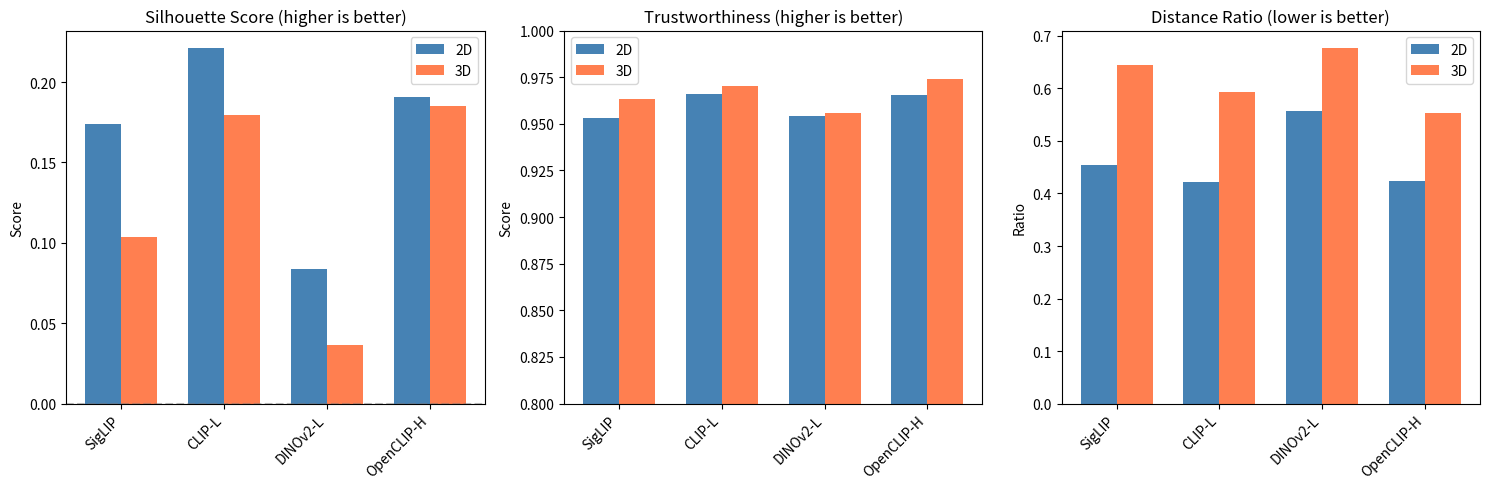

Saved: data/model_comparison_tsne.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = df.index.tolist()
x = np.arange(len(models))
width = 0.35

# シルエットスコア
ax = axes[0]
ax.bar(x - width/2, df["silhouette_2d"], width, label="2D", color="steelblue")
ax.bar(x + width/2, df["silhouette_3d"], width, label="3D", color="coral")
ax.set_ylabel("Score")
ax.set_title("Silhouette Score (higher is better)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# Trustworthiness
ax = axes[1]
ax.bar(x - width/2, df["trustworthiness_2d"], width, label="2D", color="steelblue")
ax.bar(x + width/2, df["trustworthiness_3d"], width, label="3D", color="coral")
ax.set_ylabel("Score")
ax.set_title("Trustworthiness (higher is better)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.set_ylim(0.8, 1.0)

# 距離比
ax = axes[2]
ax.bar(x - width/2, df["distance_ratio_2d"], width, label="2D", color="steelblue")
ax.bar(x + width/2, df["distance_ratio_3d"], width, label="3D", color="coral")
ax.set_ylabel("Ratio")
ax.set_title("Distance Ratio (lower is better)")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.savefig("../data/model_comparison_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: data/model_comparison_tsne.png")

## 可視化: PCA指標の比較

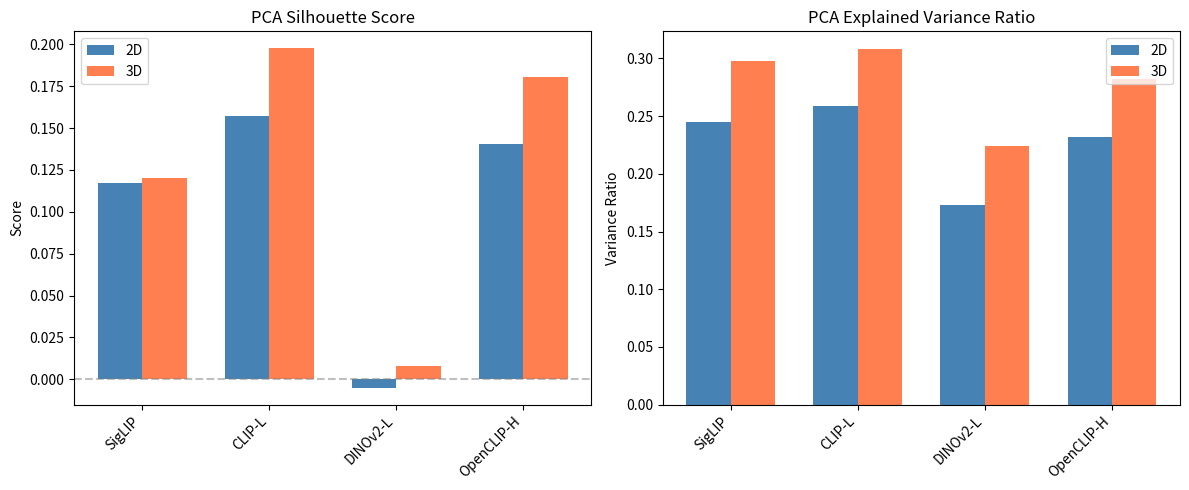

Saved: data/model_comparison_pca.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# PCAシルエットスコア
ax = axes[0]
ax.bar(x - width/2, df["pca_silhouette_2d"], width, label="2D", color="steelblue")
ax.bar(x + width/2, df["pca_silhouette_3d"], width, label="3D", color="coral")
ax.set_ylabel("Score")
ax.set_title("PCA Silhouette Score")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

# PCA累積寄与率
ax = axes[1]
ax.bar(x - width/2, df["pca_variance_2d"], width, label="2D", color="steelblue")
ax.bar(x + width/2, df["pca_variance_3d"], width, label="3D", color="coral")
ax.set_ylabel("Variance Ratio")
ax.set_title("PCA Explained Variance Ratio")
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.savefig("../data/model_comparison_pca.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: data/model_comparison_pca.png")

## 可視化: 処理性能と効率

/tmp/ipykernel_125697/1606376494.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")
/tmp/ipykernel_125697/1606376494.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")
/tmp/ipykernel_125697/1606376494.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(models, rotation=45, ha="right")


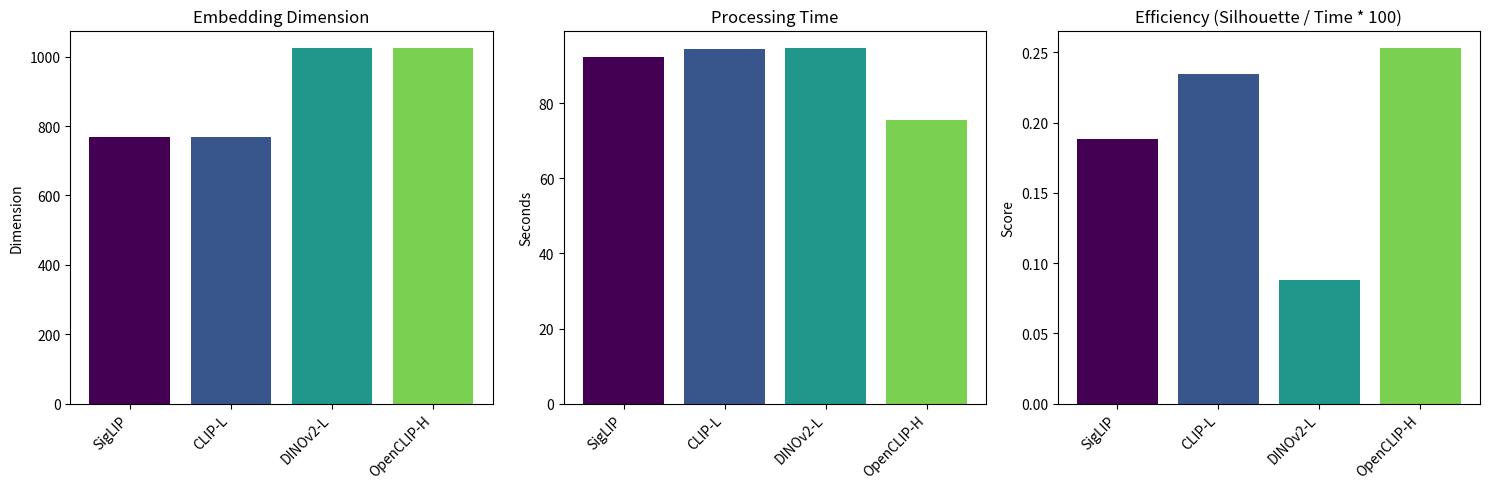

Saved: data/model_comparison_performance.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 埋め込み次元数
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.8, len(models)))
ax.bar(models, df["dim"], color=colors)
ax.set_ylabel("Dimension")
ax.set_title("Embedding Dimension")
ax.set_xticklabels(models, rotation=45, ha="right")

# 処理時間
ax = axes[1]
ax.bar(models, df["time_s"], color=colors)
ax.set_ylabel("Seconds")
ax.set_title("Processing Time")
ax.set_xticklabels(models, rotation=45, ha="right")

# 効率（シルエットスコア / 処理時間 * 100）
ax = axes[2]
efficiency = df["silhouette_2d"] / df["time_s"] * 100
ax.bar(models, efficiency, color=colors)
ax.set_ylabel("Score")
ax.set_title("Efficiency (Silhouette / Time * 100)")
ax.set_xticklabels(models, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../data/model_comparison_performance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: data/model_comparison_performance.png")

## レーダーチャート（総合比較）

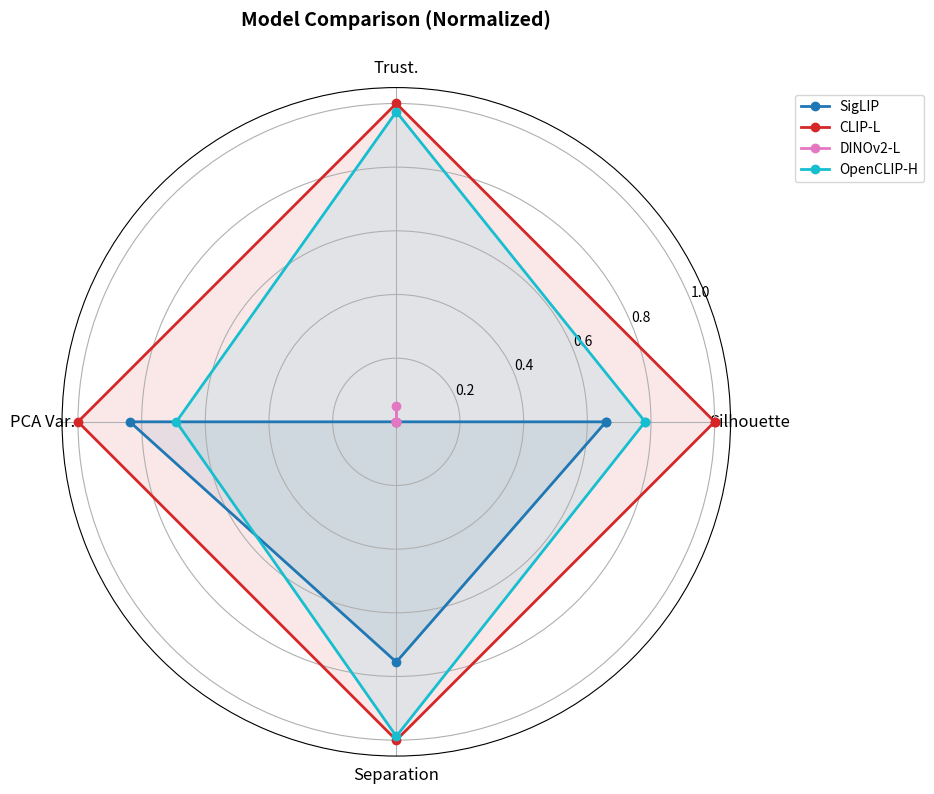

Saved: data/model_comparison_radar.png


In [8]:
from math import pi

# 評価指標を正規化（0-1スケール）
metrics_for_radar = [
    "silhouette_2d",
    "trustworthiness_2d",
    "pca_variance_2d",
]

# 距離比は低いほど良いので反転
df_radar = df[metrics_for_radar].copy()
df_radar["separation"] = 1 - df["distance_ratio_2d"].clip(0, 1)

# 各列を0-1に正規化
for col in df_radar.columns:
    col_min = df_radar[col].min()
    col_max = df_radar[col].max()
    if col_max > col_min:
        df_radar[col] = (df_radar[col] - col_min) / (col_max - col_min)
    else:
        df_radar[col] = 0.5

# レーダーチャートの設定
categories = ["Silhouette", "Trust.", "PCA Var.", "Separation"]
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # 閉じるため

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

colors = plt.cm.tab10(np.linspace(0, 1, len(df_radar)))

for i, (model, row) in enumerate(df_radar.iterrows()):
    values = row.tolist()
    values += values[:1]  # 閉じるため
    ax.plot(angles, values, "o-", linewidth=2, label=model, color=colors[i])
    ax.fill(angles, values, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_title("Model Comparison (Normalized)", size=14, fontweight="bold", y=1.08)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.savefig("../data/model_comparison_radar.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: data/model_comparison_radar.png")

## サマリーと推奨

In [9]:
print("=" * 60)
print("Model Comparison Summary")
print("=" * 60)

# 各指標でベストなモデルを特定
best_silhouette = df["silhouette_2d"].idxmax()
best_trust = df["trustworthiness_2d"].idxmax()
best_ratio = df["distance_ratio_2d"].idxmin()
fastest = df["time_s"].idxmin()

# 値を取得（ユニークインデックスが保証されているのでスカラー値）
sil_val = df.loc[best_silhouette, 'silhouette_2d']
trust_val = df.loc[best_trust, 'trustworthiness_2d']
ratio_val = df.loc[best_ratio, 'distance_ratio_2d']
time_val = df.loc[fastest, 'time_s']

print(f"\nBest Silhouette Score (2D): {best_silhouette} ({sil_val:.4f})")
print(f"Best Trustworthiness (2D):  {best_trust} ({trust_val:.4f})")
print(f"Best Distance Ratio (2D):   {best_ratio} ({ratio_val:.4f})")
print(f"Fastest Processing:         {fastest} ({time_val:.1f}s)")

print("\n" + "=" * 60)
print("Recommendations")
print("=" * 60)
print("""
- **最高品質を求める場合**: シルエットスコア・Trustworthinessが高いモデルを選択
- **処理速度を重視する場合**: 処理時間が短いモデルを選択
- **日本語検索を行う場合**: Japanese CLIP または Jina CLIP を選択
- **テキスト検索不要の場合**: DINOv2 は画像特徴抽出に特化
""")

Model Comparison Summary

Best Silhouette Score (2D): CLIP-L (0.2210)
Best Trustworthiness (2D):  CLIP-L (0.9659)
Best Distance Ratio (2D):   CLIP-L (0.4215)
Fastest Processing:         OpenCLIP-H (75.5s)

Recommendations

- **最高品質を求める場合**: シルエットスコア・Trustworthinessが高いモデルを選択
- **処理速度を重視する場合**: 処理時間が短いモデルを選択
- **日本語検索を行う場合**: Japanese CLIP または Jina CLIP を選択
- **テキスト検索不要の場合**: DINOv2 は画像特徴抽出に特化



## 比較結果のエクスポート

In [10]:
# CSVとしてエクスポート
export_df = df.reset_index()
export_df.to_csv("../data/model_comparison.csv", index=False)
print("Exported: data/model_comparison.csv")

# サマリーテーブルもエクスポート
summary_export = summary_df.reset_index()
summary_export.to_csv("../data/model_comparison_summary.csv", index=False)
print("Exported: data/model_comparison_summary.csv")

Exported: data/model_comparison.csv
Exported: data/model_comparison_summary.csv


## 評価と考察

### 総合評価

今回の評価では、6カテゴリ・385枚の画像データセットに対して4つの画像埋め込みモデルを比較した。

#### 順位表

| 順位 | モデル | 総合評価 |
|------|--------|----------|
| 1位 | **CLIP-L** (OpenAI) | シルエットスコア・Trustworthiness・距離比すべてで最高。カテゴリ分離が最も明確 |
| 2位 | **OpenCLIP-H** | 処理速度最速（75.6秒）。品質も良好で、速度と品質のバランスに優れる |
| 3位 | **SigLIP** | 中程度の性能。軽量モデル（768次元）としては健闘 |
| 4位 | **DINOv2-L** | クラスタリング品質は低い。シルエットスコアがほぼ0に近い |

### 考察

#### 1. CLIP系モデルの優位性
CLIP-LとOpenCLIP-Hが上位を占めた。これらはテキスト-画像ペアでコントラスティブ学習を行っており、**意味的なカテゴリ分離**に優れていることが確認できた。今回のデータセット（カンファレンス写真、風景写真、人物写真など）のように、視覚的特徴だけでなく「場所」や「イベント」といった意味的なカテゴリ分けが必要なタスクには適している。

#### 2. DINOv2の特性
DINOv2は教師なし自己蒸留学習で訓練されたモデルで、シルエットスコアが低かった（2D: 0.084、PCA 2D: -0.019）。これはDINOv2が**低レベルの視覚特徴**（テクスチャ、形状、色彩など）を捉えることに優れている一方、意味的なカテゴリ分離には向いていないことを示唆する。物体検出やセグメンテーションのような**ピクセルレベルのタスク**ではDINOv2の方が適している可能性がある。

#### 3. 処理速度と品質のトレードオフ
OpenCLIP-Hは処理速度が最速（75.6秒）で、CLIP-Lより約14%高速だった。品質面でもCLIP-Lに次ぐ2位であり、**本番環境での利用にはOpenCLIP-Hが実用的な選択肢**と言える。

#### 4. 次元数と性能の関係
768次元（CLIP-L、SigLIP）と1024次元（OpenCLIP-H、DINOv2）のモデルを比較したが、次元数と性能に単純な相関は見られなかった。768次元のCLIP-Lが最高性能を示しており、**モデルアーキテクチャと学習データの質**が重要であることがわかる。

### 推奨用途

| 用途 | 推奨モデル | 理由 |
|------|-----------|------|
| 画像検索・類似画像検索 | CLIP-L | カテゴリ分離が最も明確 |
| 本番環境（速度重視） | OpenCLIP-H | 速度と品質のバランスが最良 |
| テキストによる画像検索 | CLIP-L / OpenCLIP-H | マルチモーダル対応 |
| 画像の視覚的類似度 | DINOv2 | 低レベル特徴の抽出に優れる（要検証） |

### 今後の検討事項

1. **データセットの拡大**: より多様なカテゴリ・画像数での検証
2. **テキスト検索の評価**: マルチモーダルモデルのテキスト-画像検索性能の定量評価
3. **推論速度のベンチマーク**: バッチサイズや入力解像度による速度変化の調査
4. **ファインチューニング**: 特定ドメインへの適応可能性の検討